# 01. EDA (탐색적 데이터 분석)

## 목표: BDA 학회 학생의 중도포기(withdrawal) 예측

---
### 0. 라이브러리 임포트

In [6]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 메시지 숨김
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


---
### 1. 데이터 로드

In [7]:
# 데이터 로드
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
submission = pd.read_csv('./data/sample_submission.csv')

print(f"Train 데이터 크기: {train.shape}")
print(f"Test 데이터 크기: {test.shape}")
print(f"Submission 크기: {submission.shape}")

Train 데이터 크기: (1056, 46)
Test 데이터 크기: (788, 45)
Submission 크기: (788, 3)


In [8]:
# Train 데이터 첫 5행 확인
train.head()

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,...,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participitation,idea_contest,onedayclass_topic,withdrawal
0,TRAIN_0000,8,3e0057be3ecde495d1d6aab0bdc3092cce94440a6a4f68...,단일 전공,IT(컴퓨터 공학 포함),NaN,False,대학생,4,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)","온,오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 많지 않아야 편하게 들을 수 있어서,삼성이나 하이닉스,AI,NaN,NaN,C++ 응용,1
1,TRAIN_0001,8,c7c76d1a4c9d719d17c899a3ca9de153452a22163fe083...,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),False,대학생,4,NaN,...,국내 빅테크 IT 계열 (네카쿠라배당토),"온,오프라인 동시",10명 내외의 강의 리스너와 1명의 현직자,인원이 적어야 집중할 수 있고 질문 하기 쉽다.,네이버,AI,NaN,NaN,.,1
2,TRAIN_0002,8,1ed9296bd2a05ea36fabb5171a003b7320bb21a53d6135...,단일 전공,IT(컴퓨터 공학 포함),NaN,True,대학생,4,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)","온,오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 소수인원은 조금 부담스럽고 너무 많은 인원은 집중도가 떨어질거같아서,스포츠분석 기업,AI,139ac02d03d83f839197195e65bc1810ef5282ade32d80...,NaN,C언어 기초,1
3,TRAIN_0003,8,5ec50ef5a0c0416652f8d67a89ef4c02eb0c6a61b5d0a8...,단일 전공,IT(컴퓨터 공학 포함),NaN,True,대학생,7,NaN,...,국내 빅테크 IT 계열 (네카쿠라배당토),"온,오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 있을 경우 집중도가 떨어질 거 같습니다.,토스,AI,NaN,NaN,현직자의 취업과정,0
4,TRAIN_0004,8,c7c76d1a4c9d719d17c899a3ca9de153452a22163fe083...,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),False,대학생,7,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,100명 이상의 리스너와 10명 이상의 현직자,많은 현직자분들의 이야기를 듣고싶어서,네이버 카카오,금융,NaN,NaN,C언어,1


In [9]:
# 컬럼 목록 확인
print(f"총 컬럼 수: {len(train.columns)}")
print("\n컬럼 목록:")
for i, col in enumerate(train.columns, 1):
    print(f"{i:2d}. {col}")

총 컬럼 수: 46

컬럼 목록:
 1. ID
 2. generation
 3. school1
 4. major type
 5. major1_1
 6. major1_2
 7. major_data
 8. job
 9. class1
10. class2
11. class3
12. class4
13. re_registration
14. contest_award
15. nationality
16. inflow_route
17. whyBDA
18. what_to_gain
19. hope_for_group
20. previous_class_3
21. previous_class_4
22. previous_class_5
23. previous_class_6
24. previous_class_7
25. major_field
26. desired_career_path
27. completed_semester
28. project_type
29. time_input
30. desired_job
31. certificate_acquisition
32. desired_certificate
33. certificate_study_period
34. desired_job_except_data
35. incumbents_level
36. incumbents_lecture
37. incumbents_company_level
38. incumbents_lecture_type
39. incumbents_lecture_scale
40. incumbents_lecture_scale_reason
41. interested_company
42. expected_domain
43. contest_participitation
44. idea_contest
45. onedayclass_topic
46. withdrawal


---
### 2. 데이터 기본 정보

In [10]:
# 데이터 타입 및 결측치 정보
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               1056 non-null   object 
 1   generation                       1056 non-null   int64  
 2   school1                          1056 non-null   object 
 3   major type                       1049 non-null   object 
 4   major1_1                         1051 non-null   object 
 5   major1_2                         493 non-null    object 
 6   major_data                       1056 non-null   bool   
 7   job                              1056 non-null   object 
 8   class1                           1056 non-null   int64  
 9   class2                           101 non-null    float64
 10  class3                           2 non-null      float64
 11  class4                           1 non-null      float64
 12  re_registration     

In [11]:
# 수치형 변수 통계 요약
train.describe()

,generation,class1,class2,class3,class4,time_input,withdrawal
count,1056.0,1056.000000,101.000000,2.00000,1.0,1056.000000,1056.000000
mean,8.0,4.403409,5.584158,6.50000,6.0,2.353220,0.691288
std,0.0,2.534342,2.246185,2.12132,NaN,1.392345,0.462181
min,8.0,1.000000,2.000000,5.00000,6.0,0.000000,0.000000
25%,8.0,2.000000,4.000000,5.75000,6.0,2.000000,0.000000
50%,8.0,4.000000,5.000000,6.50000,6.0,2.000000,1.000000
75%,8.0,6.000000,8.000000,7.25000,6.0,3.000000,1.000000
max,8.0,10.000000,9.000000,8.00000,6.0,12.000000,1.000000


---
### 3. 결측치 분석

In [12]:
# 결측치 개수 및 비율 계산
missing = pd.DataFrame({
    '결측치 개수': train.isnull().sum(),
    '결측치 비율(%)': (train.isnull().sum() / len(train) * 100).round(2)
})

# 결측치가 있는 컬럼만 필터링
missing_cols = missing[missing['결측치 개수'] > 0].sort_values('결측치 비율(%)', ascending=False)
print(f"결측치가 있는 컬럼 수: {len(missing_cols)}개")
missing_cols

결측치가 있는 컬럼 수: 33개


,결측치 개수,결측치 비율(%)
class4,1055,99.91
class3,1054,99.81
contest_award,1045,98.96
idea_contest,1045,98.96
class2,955,90.44
previous_class_4,884,83.71
previous_class_5,884,83.71
previous_class_3,883,83.62
previous_class_7,882,83.52
previous_class_6,882,83.52


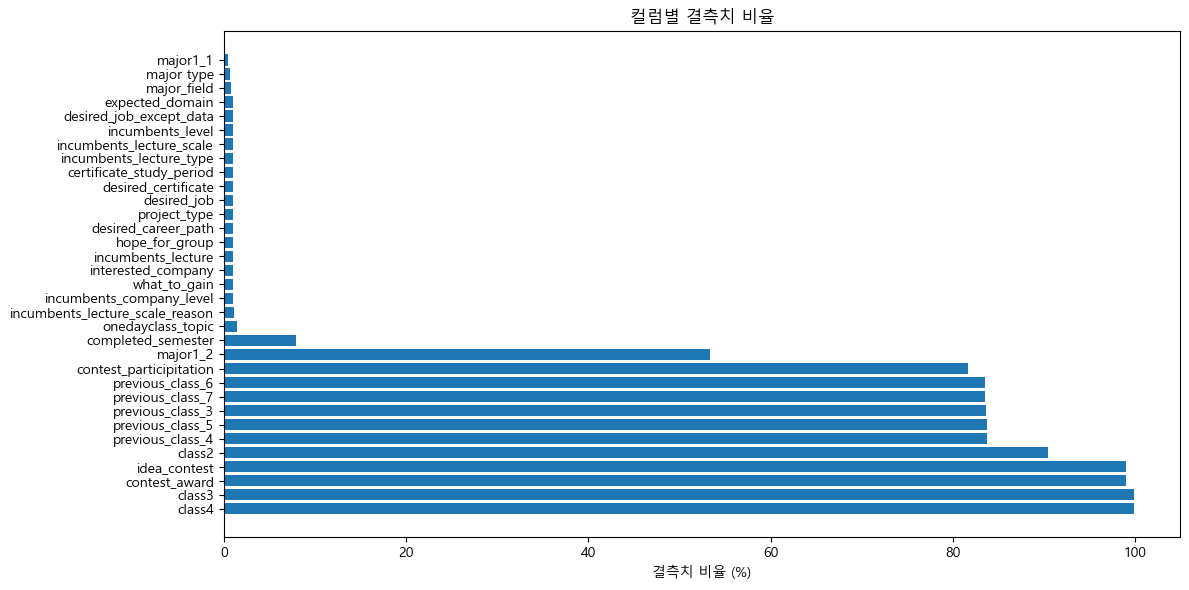

In [13]:
# 결측치 시각화
if len(missing_cols) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_cols.index, missing_cols['결측치 비율(%)'])
    plt.xlabel('결측치 비율 (%)')
    plt.title('컬럼별 결측치 비율')
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 없습니다!")

---
### 4. 타겟 변수 분석

In [14]:
# 타겟 변수 분포
print("=" * 40)
print("타겟 변수 (withdrawal) 분포")
print("=" * 40)
print(f"\n0 (유지): 학회 활동을 끝까지 완료")
print(f"1 (중도포기): 학회 활동 중 포기")
print()

target_dist = train['withdrawal'].value_counts()
target_ratio = train['withdrawal'].value_counts(normalize=True) * 100

print(f"유지 (0): {target_dist[0]:,}명 ({target_ratio[0]:.1f}%)")
print(f"중도포기 (1): {target_dist[1]:,}명 ({target_ratio[1]:.1f}%)")
print(f"\n불균형 비율: 1 : {target_dist[0]/target_dist[1]:.1f}")

타겟 변수 (withdrawal) 분포

0 (유지): 학회 활동을 끝까지 완료
1 (중도포기): 학회 활동 중 포기

유지 (0): 326명 (30.9%)
중도포기 (1): 730명 (69.1%)

불균형 비율: 1 : 0.4


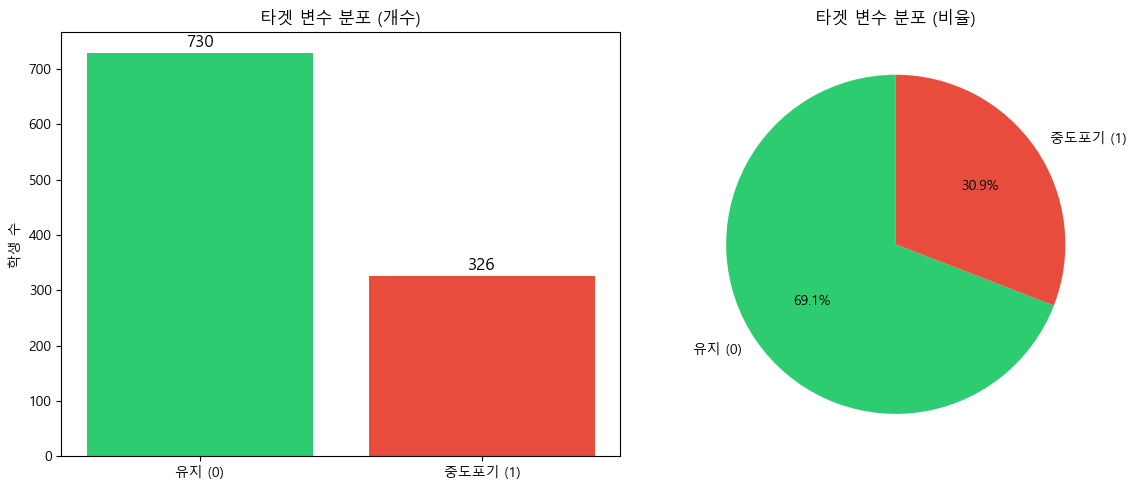

In [15]:
# 타겟 변수 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 막대 그래프
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['유지 (0)', '중도포기 (1)'], target_dist.values, color=colors)
axes[0].set_ylabel('학생 수')
axes[0].set_title('타겟 변수 분포 (개수)')
for i, v in enumerate(target_dist.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=12)

# 파이 차트
axes[1].pie(target_dist.values, labels=['유지 (0)', '중도포기 (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('타겟 변수 분포 (비율)')

plt.tight_layout()
plt.show()

---
### 5. 피처 타입 분류

In [16]:
# 수치형/범주형 컬럼 분류
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object', 'bool']).columns.tolist()

# ID와 타겟은 제외
numerical_cols = [col for col in numerical_cols if col not in ['ID', 'withdrawal']]
categorical_cols = [col for col in categorical_cols if col != 'ID']

print(f"수치형 컬럼 ({len(numerical_cols)}개): {numerical_cols}")
print(f"범주형 컬럼 ({len(categorical_cols)}개): {categorical_cols}")

수치형 컬럼 (6개): ['generation', 'class1', 'class2', 'class3', 'class4', 'time_input']
범주형 컬럼 (38개): ['school1', 'major type', 'major1_1', 'major1_2', 'major_data', 'job', 're_registration', 'contest_award', 'nationality', 'inflow_route', 'whyBDA', 'what_to_gain', 'hope_for_group', 'previous_class_3', 'previous_class_4', 'previous_class_5', 'previous_class_6', 'previous_class_7', 'major_field', 'desired_career_path', 'completed_semester', 'project_type', 'desired_job', 'certificate_acquisition', 'desired_certificate', 'certificate_study_period', 'desired_job_except_data', 'incumbents_level', 'incumbents_lecture', 'incumbents_company_level', 'incumbents_lecture_type', 'incumbents_lecture_scale', 'incumbents_lecture_scale_reason', 'interested_company', 'expected_domain', 'contest_participitation', 'idea_contest', 'onedayclass_topic']


---
### 6. 범주형 변수 분석

In [17]:
# 범주형 변수별 중도포기율 분석 함수
def analyze_categorical(df, col, target='withdrawal'):
    """범주형 변수와 타겟 변수의 관계를 분석합니다."""
    # 그룹별 통계
    stats = df.groupby(col)[target].agg(['count', 'sum', 'mean'])
    stats.columns = ['전체', '중도포기', '중도포기율']
    stats['중도포기율'] = (stats['중도포기율'] * 100).round(1)
    stats = stats.sort_values('중도포기율', ascending=False)
    return stats

In [18]:
# 모든 범주형 변수별 중도포기율 분석
for col in categorical_cols:
    print("=" * 50)
    print(f"[{col}] 중도포기율")
    print("=" * 50)
    display(analyze_categorical(train, col))
    print()

[school1] 중도포기율


,전체,중도포기,중도포기율
school1,,,
0f58c972de186460afcc83969eed26b264b9602296d69aa12776e0acfc841db5,1,1,100.0
33ab19f8b130d966ff0794d2063bce75480010336329e9d3ba59446043b8c2ad,9,9,100.0
1cecb9335912521d59e606bc3138022178747c2895801b12ff2735cfa8964021,1,1,100.0
85e4b2ca096c320273b4657da251ad23d2ae671b3653a0feb3af257d1589b26b,2,2,100.0
84e40c965cf842a35eab0fba156e6ad733ad08eb72183300497095170fe6793e,2,2,100.0
...,...,...,...
5ace6c485a4eea084276f15fc19c286b5a333abecb32c7c86ae0773be23737d8,1,0,0.0
b984cad4142c6f84897b2444397da95ee1d736e318113f2a4d700de61532a5e2,1,0,0.0
9aa860526c460712ebc8ee3b26c813c61d767b9d7df5751322366e937180f27c,1,0,0.0



[major type] 중도포기율


,전체,중도포기,중도포기율
major type,,,
단일 전공,583,404,69.3
"복수 전공 ( 다중전공, 이중전공 포함 )",466,320,68.7



[major1_1] 중도포기율


...

,전체,중도포기,중도포기율
contest_participitation,,,
03beb29d880b00225df3af55f954b51d739ecf00330da8d885d6b693adeb222b,1,1,100.0
04146ae903914cfde1ce9552f6697735222b3970004d581e60045cdabcfe2540,1,1,100.0
052a116d2d3693d9521cbb9ba6481247b9fa200f1fcc57d3915fcb9aff19e43d,1,1,100.0
07890f817ea3add47a55c2cba06dd01185dc179257e1681f31f4185fd64462fd,1,1,100.0
091ecc3c591cb8fb044868df075b3000da83ba0782d531a027e707b795d0f794,1,1,100.0
...,...,...,...
e757c0081fcac997af7fbeb5461b77321bf628ae391e4455351fe8e154507182,1,0,0.0
ec993c0a4ffc2a9757440e3d0d80a217a4926b73ece1a8597ff0f235536bebd2,1,0,0.0
ea4eb638504f310ea8df1c9d3378e40a87dc2e7f7dc2cd5afe41bd53c429a443,1,0,0.0



[idea_contest] 중도포기율


,전체,중도포기,중도포기율
idea_contest,,,
2662a732dc959e9f34d0380bd07e546bd073623eb4c69545829893673edff08d,1,1,100.0
3db7e731e6a0912ba0a7feee2a8b5f258b142217c9033efec46f1c70bf24e3e6,1,1,100.0
424f25d21846bcc809140d82de7a061a75810a1265ea56e980e40810780a8f96,1,1,100.0
cb201dea598897eac330f034c285419a259baf83a9fe451469320f2d7eb8367f,1,1,100.0
58449c3fd12a25b87254d25bc74c931549b8ed598a158551c48e1a8eb4bb6d71,1,1,100.0
9bf1cef00eaf0656a1dba6113be1079f376945fdd46c0047a797d8ef243f82a2,1,1,100.0
a83d7f2b72636df195f88e10f74bb6a03d30ea70d6a9c47d9f9ee347306f59d3,1,1,100.0
f2c7c05b8fede89af2bd8942fda8032d3b3df724608e6f5f26a8a504dbad9427,1,1,100.0
dae9032994de6dedaf5d95bda39d8e53247f44c0312bfbbcea925a10cdb3fdd3,1,1,100.0



[onedayclass_topic] 중도포기율


,전체,중도포기,중도포기율
onedayclass_topic,,,
"회귀분석, 수리통계학과 같은 데이터/통계 개념 강의",1,1,100.0
(마케팅와 연관된) 데이터 분석 및 활용 실습,1,1,100.0
현직자 직무역량,1,1,100.0
현직자 강연,1,1,100.0
2,1,1,100.0
...,...,...,...
파이썬 활용,1,0,0.0
2학기에도 모델링1반이 있었으면 좋겠습니다,1,0,0.0
파이썬orR을 이용한 반도체데이터분석,1,0,0.0


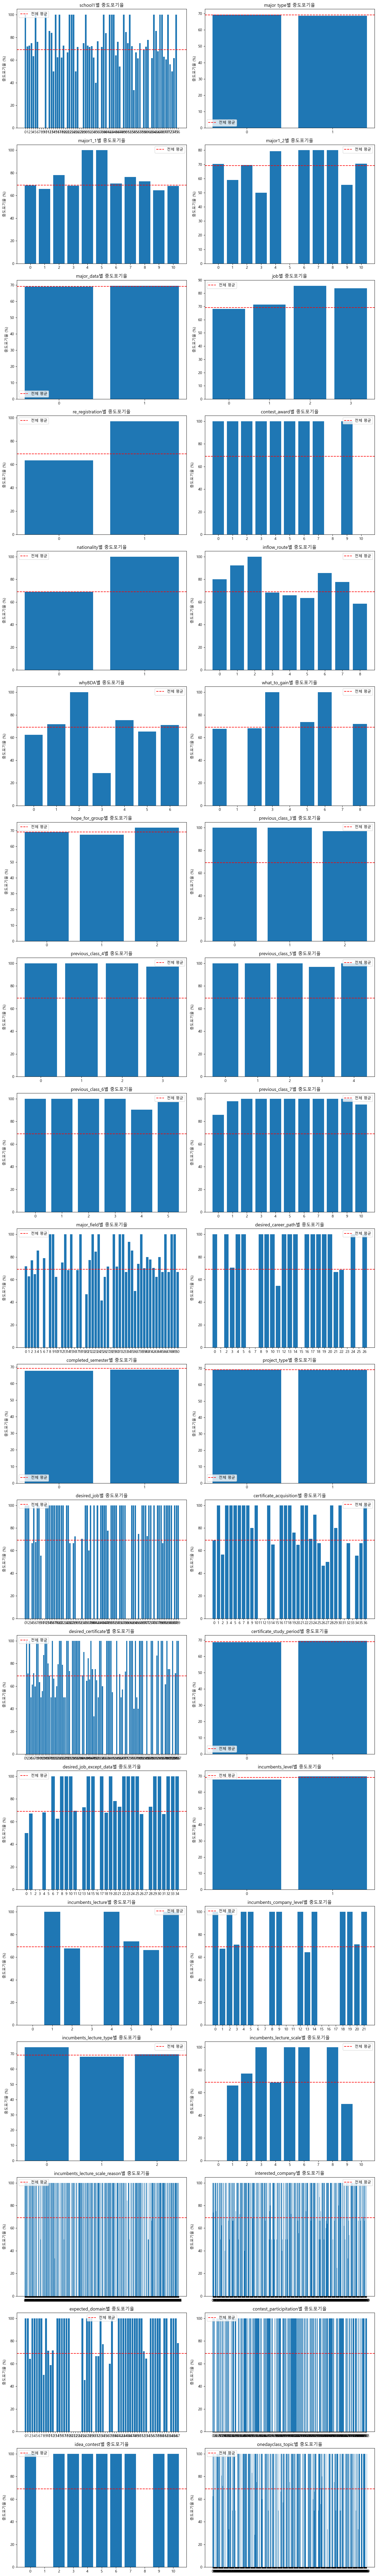

In [19]:
# 범주형 변수별 중도포기율 시각화
n_cols = 2
n_rows = (len(categorical_cols) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    withdrawal_rate = train.groupby(col)['withdrawal'].mean() * 100
    ax.bar(range(len(withdrawal_rate)), withdrawal_rate.values)
    ax.set_xticks(range(len(withdrawal_rate)))
    # ax.set_xticklabels(withdrawal_rate.index, rotation=45, ha='right')
    ax.set_ylabel('중도포기율 (%)')
    ax.set_title(f'{col}별 중도포기율')
    ax.axhline(y=train['withdrawal'].mean()*100, color='red', linestyle='--', label='전체 평균')
    ax.legend()

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

---
### 7. 수치형 변수 분석

In [20]:
# 수치형 변수 통계
if len(numerical_cols) > 0:
    print("수치형 변수 통계:")
    display(train[numerical_cols].describe())
else:
    print("수치형 변수가 없습니다.")

수치형 변수 통계:


,generation,class1,class2,class3,class4,time_input
count,1056.0,1056.000000,101.000000,2.00000,1.0,1056.000000
mean,8.0,4.403409,5.584158,6.50000,6.0,2.353220
std,0.0,2.534342,2.246185,2.12132,NaN,1.392345
min,8.0,1.000000,2.000000,5.00000,6.0,0.000000
25%,8.0,2.000000,4.000000,5.75000,6.0,2.000000
50%,8.0,4.000000,5.000000,6.50000,6.0,2.000000
75%,8.0,6.000000,8.000000,7.25000,6.0,3.000000
max,8.0,10.000000,9.000000,8.00000,6.0,12.000000


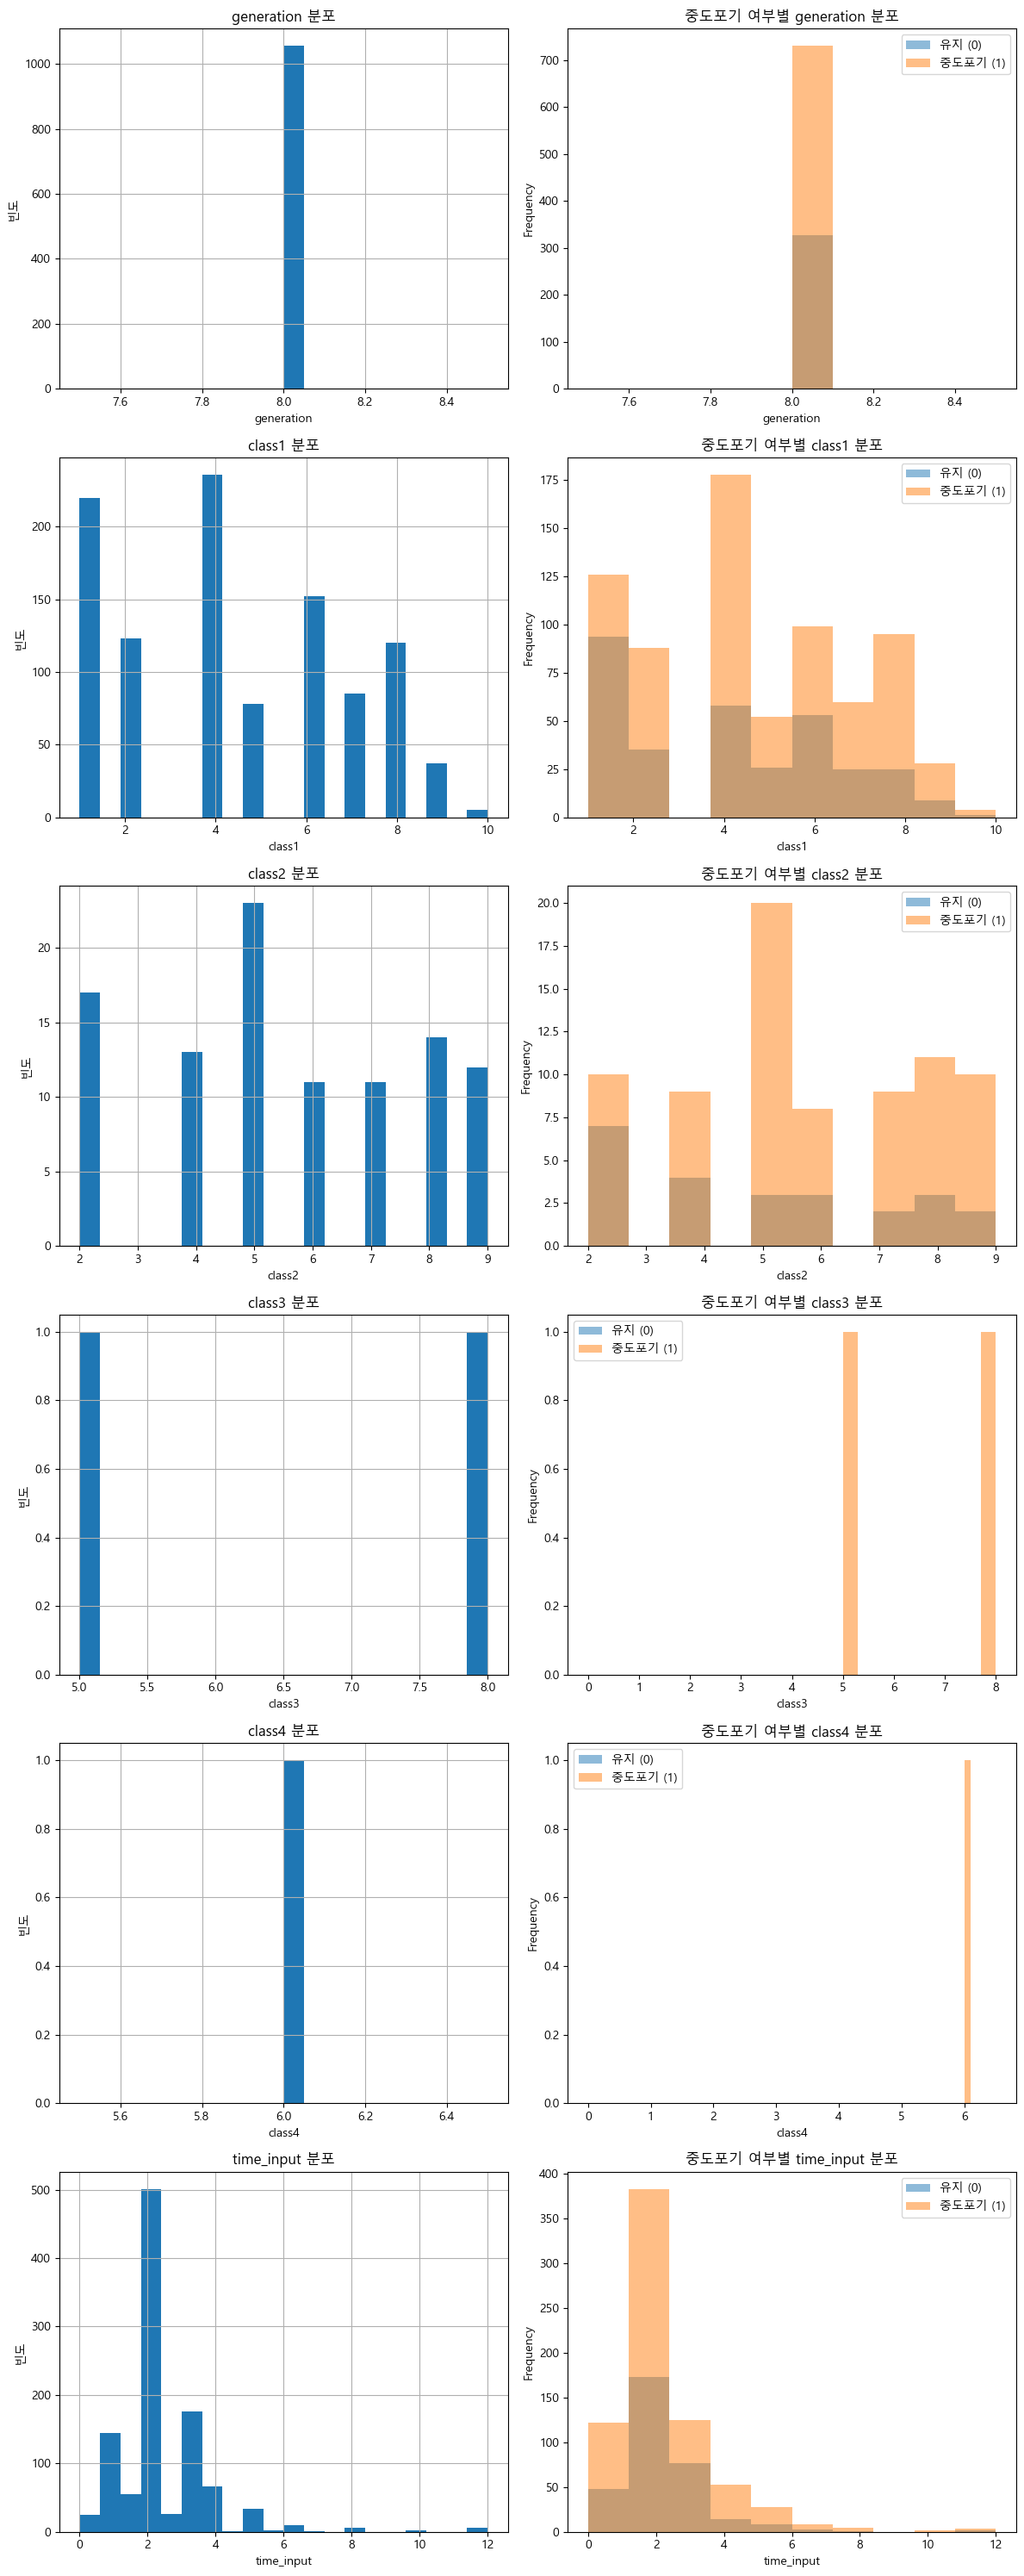

In [21]:
# 수치형 변수별 분포 및 중도포기 여부 비교
n_cols = 2
n_rows = len(numerical_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numerical_cols):
    # 전체 분포
    train[col].hist(ax=axes[idx, 0], bins=20)
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('빈도')
    axes[idx, 0].set_title(f'{col} 분포')

    # 타겟별 분포
    train.groupby('withdrawal')[col].plot(kind='hist', alpha=0.5, ax=axes[idx, 1], legend=True)
    axes[idx, 1].set_xlabel(col)
    axes[idx, 1].set_title(f'중도포기 여부별 {col} 분포')
    axes[idx, 1].legend(['유지 (0)', '중도포기 (1)'])

plt.tight_layout()
plt.show()

---
### 8. 인사이트 정리

EDA를 통해 발견한 주요 인사이트 정리

In [22]:
# 전체 중도포기율
overall_rate = train['withdrawal'].mean() * 100

print("=" * 60)
print("EDA 인사이트 요약")
print("=" * 60)
print(f"\n1. 전체 중도포기율: {overall_rate:.1f}%")
print(f"\n2. 데이터 크기: {train.shape[0]:,}명, {train.shape[1]}개 피처")
print(f"\n3. 결측치가 있는 컬럼: {len(missing_cols)}개")

# 중도포기율이 높은/낮은 그룹 찾기
print("\n4. 주요 발견사항:")
for col in ['job', 'major type', 're_registration']:
    if col in train.columns:
        rates = train.groupby(col)['withdrawal'].mean() * 100
        max_cat = rates.idxmax()
        min_cat = rates.idxmin()
        print(f"   - {col}: {max_cat} ({rates[max_cat]:.1f}%) vs {min_cat} ({rates[min_cat]:.1f}%)")

EDA 인사이트 요약

1. 전체 중도포기율: 69.1%

2. 데이터 크기: 1,056명, 46개 피처

3. 결측치가 있는 컬럼: 33개

4. 주요 발견사항:
   - job: 직장인 (85.7%) vs 대학생 (68.2%)
   - major type: 단일 전공 (69.3%) vs 복수 전공 ( 다중전공, 이중전공 포함 ) (68.7%)
   - re_registration: 예 (97.1%) vs 아니요 (63.6%)


In [23]:
!python -m pip freeze > requirements.txt